# Explore Reactome
Exploring Reactome from a network perspective

## Loading the node and edge info 

In [1]:
from lipinet.parse_reactome import parse_reactome_data 

reactome_results = parse_reactome_data(verbose=True, use_cache=True)
df_reactome_nodes = reactome_results['df_nodes']
df_reactome_edges = reactome_results['df_edges']

↪ loading Reactome (processed) from cache: reactome_human_nb


In [2]:
df_reactome_nodes

,node_id,layer,source_db_identifier,reactome_pe_name,species,pe_name,pe_location,human,url,event_name_pathway_or_reaction,evidence_code,name
0,10033,reactome_chebi,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN
1,10036,reactome_chebi,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN
2,10055,reactome_chebi,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN
3,10093,reactome_chebi,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN
4,10100,reactome_chebi,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
169357,autophagosome membrane,reactome_physicalent_loc,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN
169358,lamellar body,reactome_physicalent_loc,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN
169359,lamellar body membrane,reactome_physicalent_loc,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN
169360,clathrin-sculpted gamma-aminobutyric acid tran...,reactome_physicalent_loc,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN


In [3]:
df_reactome_edges

,source_id,target_id,source_layer,target_layer,source_db_identifier,reactome_pe_name,url,event_name_pathway_or_reaction,evidence_code,species,human,pe_name,pe_location,name,interlayer
0,10033,R-ALL-9014945,reactome_chebi,reactome_physicalent,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN
1,10036,R-ALL-5696412,reactome_chebi,reactome_physicalent,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN
2,10055,R-ALL-9611688,reactome_chebi,reactome_physicalent,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN
3,10093,R-ALL-9648287,reactome_chebi,reactome_physicalent,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN
4,10093,R-ALL-3296452,reactome_chebi,reactome_physicalent,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
697167,R-XTR-9958790,R-XTR-427652,reactome_pathway_ontology,reactome_pathway_ontology,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN,False
697168,R-XTR-9958790,R-XTR-433137,reactome_pathway_ontology,reactome_pathway_ontology,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN,False
697169,R-XTR-9958863,R-XTR-352230,reactome_pathway_ontology,reactome_pathway_ontology,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN,False
697170,R-XTR-9958863,R-XTR-428559,reactome_pathway_ontology,reactome_pathway_ontology,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN,False


In [4]:
from graph_tool.all import Graph, GraphView, graph_draw
import graph_tool as gt

from onionnet import OnionNet
import onionnet.visualisation

import pandas as pd

import onionnet.exporter 

## Building the network with OnionNet

In [5]:
onion = OnionNet()

onion.grow_onion(df_nodes=df_reactome_nodes,
           df_edges=df_reactome_edges,
           node_prop_cols=df_reactome_nodes.columns.to_list(),
           edge_prop_cols=df_reactome_edges.columns.to_list(),
           drop_na=True,
           drop_duplicates=True)

Nodes: in=55191, dropped_na=0, deduped=1017 → final=54174
Edges: in=164767, dropped_invalid=3018, deduped=8285 → final=133171


Note that we have some dedupes, would need to carefully consider if this has led to a loss of information or corruption.

In [6]:
onion.core.graph

<Graph object, directed, with 54174 vertices and 133171 edges, 14 internal vertex properties, 15 internal edge properties, at 0x3313b26c0>

In [8]:
list(onion.core.graph.vp)

['layer_hash',
 'node_id_hash',
 'node_id',
 'layer',
 'source_db_identifier',
 'reactome_pe_name',
 'species',
 'pe_name',
 'pe_location',
 'human',
 'url',
 'event_name_pathway_or_reaction',
 'evidence_code',
 'name']

In [9]:
df_reactome_nodes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 55191 entries, 0 to 169361
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   node_id                         55191 non-null  object 
 1   layer                           55191 non-null  object 
 2   source_db_identifier            6277 non-null   float64
 3   reactome_pe_name                6277 non-null   object 
 4   species                         42032 non-null  object 
 5   pe_name                         12199 non-null  string 
 6   pe_location                     12199 non-null  string 
 7   human                           18875 non-null  object 
 8   url                             12598 non-null  object 
 9   event_name_pathway_or_reaction  12598 non-null  object 
 10  evidence_code                   12598 non-null  object 
 11  name                            26299 non-null  object 
dtypes: float64(1), object(9), string(2)


Decode property labels that were encoded 

In [10]:
onion.decode_property_labels_bulk(df=df_reactome_nodes, encoded_prop_type='v')

V property 'node_id_decoded' created successfully.
V property 'layer_decoded' created successfully.
source_db_identifier prop left as is, no decoding needed (not an object type)
V property 'reactome_pe_name_decoded' created successfully.
V property 'species_decoded' created successfully.
pe_name prop left as is, no decoding needed (not an object type)
pe_location prop left as is, no decoding needed (not an object type)
V property 'human_decoded' created successfully.
V property 'url_decoded' created successfully.
V property 'event_name_pathway_or_reaction_decoded' created successfully.
V property 'evidence_code_decoded' created successfully.
V property 'name_decoded' created successfully.


In [ ]:
onion.decode_property_labels_bulk(df=df_reactome_edges, encoded_prop_type='e')

E property 'source_id_decoded' created successfully.
E property 'target_id_decoded' created successfully.
E property 'ec_level_decoded' created successfully.
E property 'source_layer_decoded' created successfully.
E property 'target_layer_decoded' created successfully.
interlayer prop left as is, no decoding needed (not an object type)
E property 'edge_type_decoded' created successfully.


In [ ]:
df_reactome_edges.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108439 entries, 0 to 108438
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   source_id     108439 non-null  object
 1   target_id     98225 non-null   object
 2   ec_level      6482 non-null    object
 3   source_layer  108439 non-null  object
 4   target_layer  108439 non-null  object
 5   interlayer    108439 non-null  bool  
 6   edge_type     108439 non-null  object
dtypes: bool(1), object(6)
memory usage: 5.1+ MB


In [ ]:
onion.core.layer_code_to_name

{0: 'rhea_reactionid', 1: 'rhea_chebiid', 2: 'rhea_ec'}

## Inspecting LipiNet metagraph for Reactome

In [11]:
from onionnet.analytics import layer_stats, plot_layer_metagraph

nodes_by_layer, edges_by_pair = layer_stats(
    df_nodes=df_reactome_nodes,
    df_edges=df_reactome_edges,
    print_tables=True
)


Node counts by layer:


,count
layer,
reactome_pathway_ontology,23157
reactome_reactions,9456
reactome_physicalent,6277
reactome_physicalent_nameloc,5922
reactome_physicalent_name,4084
reactome_pathway,3142
reactome_chebi,3068
reactome_physicalent_loc,85



Interlayer edge count: 0
Edge counts by (source_layer, target_layer):


edges
source_layer                 target_layer                       
reactome_physicalent         reactome_pathway              57728
                             reactome_reactions            35704
reactome_pathway_ontology    reactome_pathway_ontology     23259
reactome_pathway             reactome_ontology_pathways    20860
reactome_chebi               reactome_physicalent           6353
reactome_physicalent_nameloc reactome_physicalent           6001
reactome_physicalent_loc     reactome_physicalent_nameloc   5922
reactome_physicalent_name    reactome_physicalent_nameloc   5922

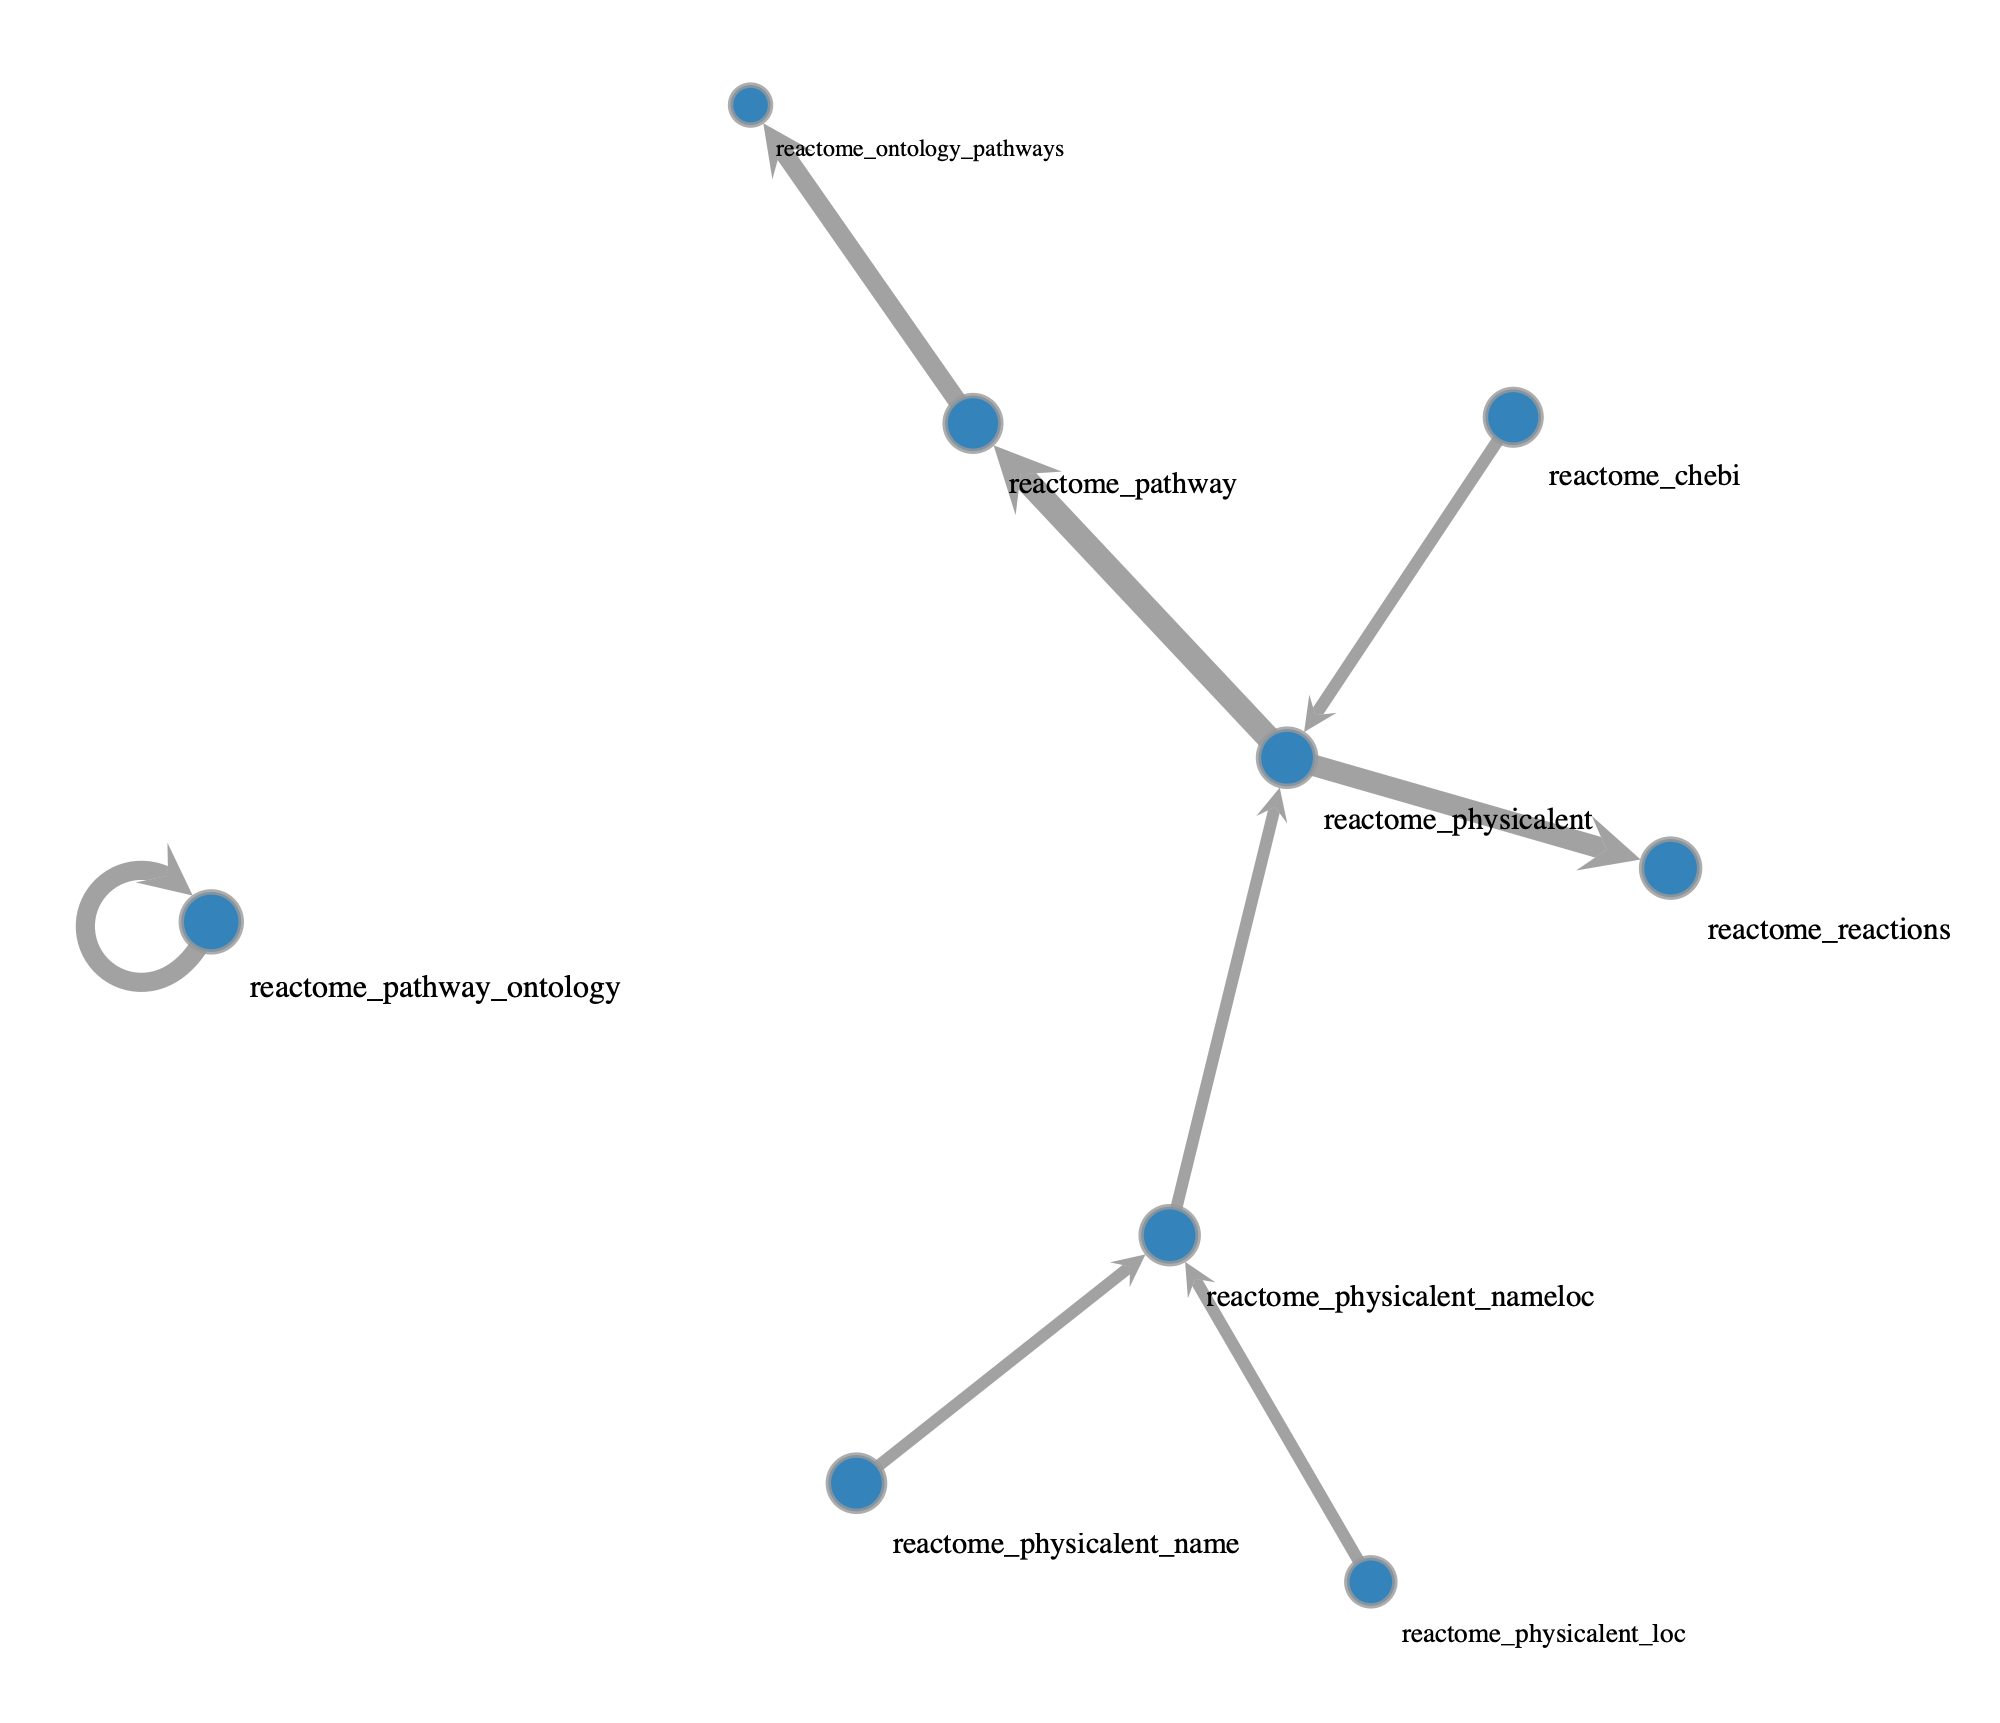

In [12]:
mg, mg_pos = plot_layer_metagraph(
    edges_by_pair,
    nodes_by_layer=nodes_by_layer,
    node_size_range=(20, 30),
    node_text_size_range=(12, 16),
    edge_width_range=(6, 12),
    node_scaler="log",
    edge_scaler="log",
    show_labels=True,
    output_size=(1000, 1000),
    node_text_position=1,
    return_graph=True,
    # pad_label_string=True,
    # vertex_font='consolas',
    # family_extractor=my_family,
    # family_colors={"sl": (0.2,0.6,0.9,0.9), "rhea": (0.9,0.4,0.1,0.9)}
)

### More TODO - notebook in progress